# Portfolio 1 — Bayesian Analysis: Vitamin A & Vaccine Response
## Notebook 02: Exploratory Analysis

**Goal:** Show *why* the frequentist analysis is insufficient and motivate the Bayesian approach.

Steps:
1. Calculate seroconversion rates with Wilson 95% confidence intervals
2. Visualise with bar chart + error bars
3. Run Fisher's exact test (frequentist)
4. Compute observed Odds Ratios with CIs — forest plot
5. Summarise "Why Bayesian?"


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats
from statsmodels.stats.proportion import proportion_confint

## Section 1: Load the data

In [2]:
df = pd.read_csv("../data/simulated_patient_data.csv")
print(df.shape)
df.head()

(66, 4)


,participant_id,season,treatment,seroconverted
0,1,S2,A&D,1
1,2,S2,A&D,0
2,3,S2,A&D,0
3,4,S2,A&D,1
4,5,S2,A&D,1


## Section 2: Seroconversion rates per group

In [3]:
summary = df.groupby(['season', 'treatment']).agg(
    n_total=('participant_id', 'count'),
    n_seroconverted=('seroconverted', 'sum')
).reset_index()
summary['rate'] = summary['n_seroconverted'] / summary['n_total']
summary

,season,treatment,n_total,n_seroconverted,rate
0,S2,A&D,21,15,0.714286
1,S2,Placebo,20,19,0.950000
2,S3,A&D,11,8,0.727273
3,S3,Placebo,14,12,0.857143


## Section 3: Add Wilson 95% Confidence Intervals

Wilson intervals are preferred for proportions — they handle small samples and extreme rates better than the normal approximation.

In [4]:
def wilson_ci(n_success, n_total):
    lower, upper = proportion_confint(n_success, n_total, alpha=0.05, method='wilson')
    return lower, upper

for idx, row in summary.iterrows():
    lower, upper = wilson_ci(row['n_seroconverted'], row['n_total'])
    summary.loc[idx, 'ci_lower'] = lower
    summary.loc[idx, 'ci_upper'] = upper

summary['rate_pct']     = summary['rate']     * 100
summary['ci_lower_pct'] = summary['ci_lower'] * 100
summary['ci_upper_pct'] = summary['ci_upper'] * 100

summary.round(3)

,season,treatment,n_total,n_seroconverted,rate,ci_lower,ci_upper,rate_pct,ci_lower_pct,ci_upper_pct
0,S2,A&D,21,15,0.714,0.500,0.862,71.429,50.044,86.186
1,S2,Placebo,20,19,0.950,0.764,0.991,95.000,76.387,99.112
2,S3,A&D,11,8,0.727,0.434,0.903,72.727,43.435,90.254
3,S3,Placebo,14,12,0.857,0.601,0.960,85.714,60.059,95.991


## Section 4: Bar chart with error bars

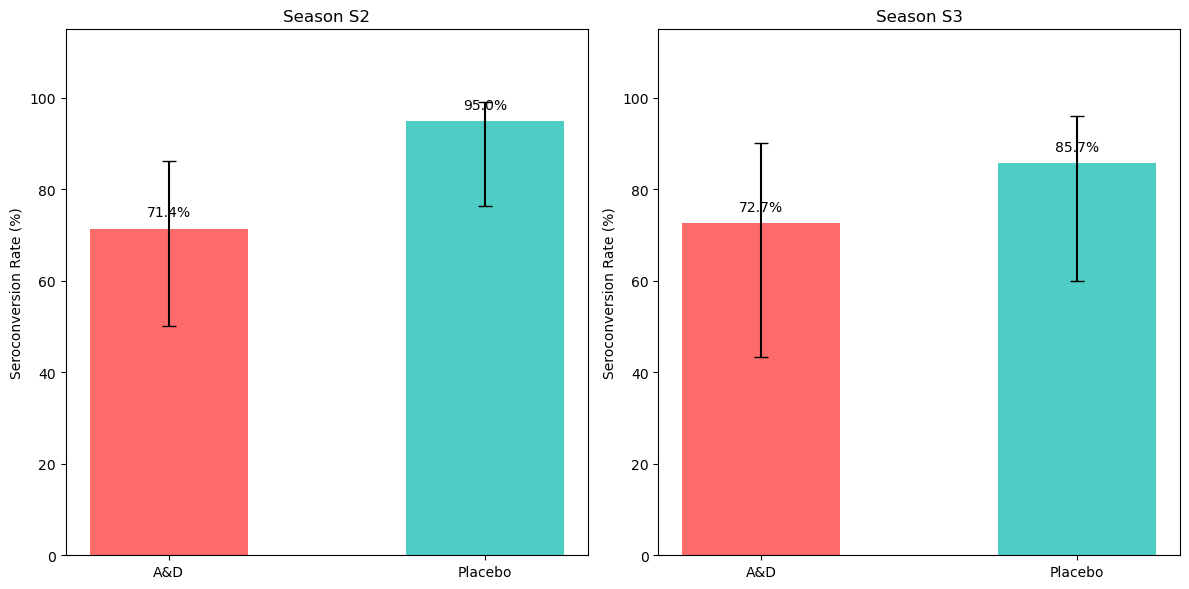

Saved: ../figures/02_seroconversion_with_ci.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, season in zip(axes, ['S2', 'S3']):
    season_data = summary[summary['season'] == season].reset_index(drop=True)

    ax.bar(np.arange(2), season_data['rate_pct'], width=0.5, color=['#FF6B6B', '#4ECDC4'])

    for i, row in season_data.iterrows():
        lower_err = row['rate_pct'] - row['ci_lower_pct']
        upper_err = row['ci_upper_pct'] - row['rate_pct']
        ax.errorbar(i, row['rate_pct'], yerr=[[lower_err], [upper_err]],
                    fmt='none', color='black', capsize=5)

    for i, row in season_data.iterrows():
        ax.text(i, row['rate_pct'] + 2, f"{row['rate_pct']:.1f}%", ha='center', va='bottom')

    ax.set_title(f'Season {season}')
    ax.set_ylabel('Seroconversion Rate (%)')
    ax.set_xticks(np.arange(2))
    ax.set_xticklabels(season_data['treatment'])
    ax.set_ylim(0, 115)

plt.tight_layout()
plt.savefig('../figures/02_seroconversion_with_ci.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: ../figures/02_seroconversion_with_ci.png")

## Section 5: Fisher's Exact Test (frequentist)

Fisher's exact test is the appropriate test for small-sample 2×2 contingency tables.
The p-value answers: "If there were truly no treatment effect, how often would we see data this extreme by chance?

In [6]:
for season in ['S2', 'S3']:
    ad_row      = summary[(summary['season'] == season) & (summary['treatment'] == 'A&D')].iloc[0]
    placebo_row = summary[(summary['season'] == season) & (summary['treatment'] == 'Placebo')].iloc[0]

    ad_failures      = ad_row['n_total']      - ad_row['n_seroconverted']
    placebo_failures = placebo_row['n_total'] - placebo_row['n_seroconverted']
    table = [[ad_row['n_seroconverted'], ad_failures],
             [placebo_row['n_seroconverted'], placebo_failures]]

    odds_ratio, p_value = scipy.stats.fisher_exact(table)
    print(f"Season {season}")
    print(f"  Table: {table}")
    print(f"  OR = {odds_ratio:.3f}  |  p = {p_value:.3f}  |  Significant: {p_value < 0.05}")
    print()

Season S2
  Table: [[15, 6], [19, 1]]
  OR = 0.132  |  p = 0.093  |  Significant: False

Season S3
  Table: [[8, 3], [12, 2]]
  OR = 0.444  |  p = 0.623  |  Significant: False



## Section 6: Forest Plot of Observed Odds Ratios

Both seasons show OR < 1 (A&D associated with *lower* seroconversion) but wide CIs crossing 1.0 — 'not significant' but not the same as 'no effect'.

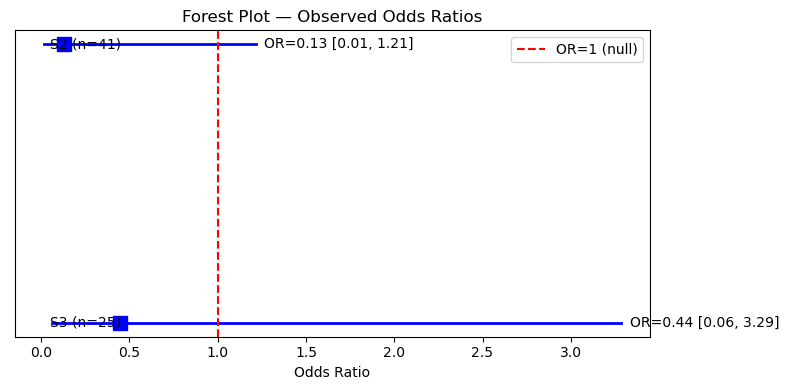

Saved: ../figures/02_forest_plot_observed.png


In [7]:
def odds_ratio_ci(n1_success, n1_total, n2_success, n2_total):
    n1_fail = n1_total - n1_success
    n2_fail = n2_total - n2_success
    OR      = (n1_success / n1_fail) / (n2_success / n2_fail)
    log_OR  = np.log(OR)
    se      = np.sqrt(1/n1_success + 1/n1_fail + 1/n2_success + 1/n2_fail)
    return OR, np.exp(log_OR - 1.96 * se), np.exp(log_OR + 1.96 * se)

results = {}
for season in ['S2', 'S3']:
    ad = summary[(summary['season'] == season) & (summary['treatment'] == 'A&D')].iloc[0]
    pl = summary[(summary['season'] == season) & (summary['treatment'] == 'Placebo')].iloc[0]
    OR, ci_lower, ci_upper = odds_ratio_ci(ad['n_seroconverted'], ad['n_total'],
                                            pl['n_seroconverted'], pl['n_total'])
    results[season] = (OR, ci_lower, ci_upper)

fig, ax = plt.subplots(figsize=(8, 4))
for y, season in zip([2, 1], ['S2', 'S3']):
    OR, ci_lower, ci_upper = results[season]
    n = summary[summary['season'] == season]['n_total'].sum()
    ax.plot([ci_lower, ci_upper], [y, y], 'b-', linewidth=2)
    ax.plot(OR, y, 's', color='blue', markersize=10)
    ax.text(ci_upper + 0.05, y, f"OR={OR:.2f} [{ci_lower:.2f}, {ci_upper:.2f}]", va='center')
    ax.text(0.05, y, f"{season} (n={n})", va='center', ha='left')

ax.axvline(1.0, color='red', linestyle='--', label='OR=1 (null)')
ax.set_yticks([])
ax.set_xlabel('Odds Ratio')
ax.set_title('Forest Plot — Observed Odds Ratios')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/02_forest_plot_observed.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: ../figures/02_forest_plot_observed.png")

## Section 7: Why Bayesian? — Summary

In [8]:
print("WHY BAYESIAN? — Summary")
print("=" * 60)

for season in ['S2', 'S3']:
    OR, ci_lower, ci_upper = results[season]
    crosses_null = ci_lower < 1.0 < ci_upper
    print(f"\nSeason {season}:")
    print(f"  OR = {OR:.2f}, 95% CI = [{ci_lower:.2f}, {ci_upper:.2f}]")
    print(f"  CI crosses 1.0: {crosses_null} → {'NOT significant' if crosses_null else 'Significant'}")
    print(f"  Wide CI = high uncertainty — 'not significant' is not the same as 'no effect'")

print('''
What the Bayesian model adds:
  - P(OR < 1 | data): direct probability that A&D reduces seroconversion
  - 95% Credible Interval: where the true OR likely lies given the data
  - Prior sensitivity: does the conclusion change with different priors?

Frequentist verdict: 'not significant' (p > 0.30)
Bayesian question:   'what is the probability there is an effect?'
''')

WHY BAYESIAN? — Summary

Season S2:
  OR = 0.13, 95% CI = [0.01, 1.21]
  CI crosses 1.0: True → NOT significant
  Wide CI = high uncertainty — 'not significant' is not the same as 'no effect'

Season S3:
  OR = 0.44, 95% CI = [0.06, 3.29]
  CI crosses 1.0: True → NOT significant
  Wide CI = high uncertainty — 'not significant' is not the same as 'no effect'

What the Bayesian model adds:
  - P(OR < 1 | data): direct probability that A&D reduces seroconversion
  - 95% Credible Interval: where the true OR likely lies given the data
  - Prior sensitivity: does the conclusion change with different priors?

Frequentist verdict: 'not significant' (p > 0.30)
Bayesian question:   'what is the probability there is an effect?'

